In [4]:
import numpy as np
import os

def finalize_clean_with_safety_gap(dat_dir="/root/autodl-tmp/validate/0218/final_measured_data_v5/", output_dir="./dataset_final_ready_v5/"):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    fs = 200e3
    # 物理帧参数
    L_sync = 512
    L_tag = 32
    L_pay = 1024
    frame_len = L_sync + L_tag + L_pay  # 总长度 1568

    # --- 核心改进：设置安全冗余 (Safety Gap) ---
    # 我们不在 544 点准时开始，而是跳到 608 点 (544 + 64)
    # 这样能彻底避开标签桩的拖尾效应和硬件处理延迟
    safety_offset = 64 
    start_pos = L_sync + L_tag + safety_offset
    # 为了保持输入长度为 1024，我们取 608 到 1568 之间的部分 (共 960 点)
    # 然后通过补零或截取保持一致
    effective_len = 960 

    files = sorted([f for f in os.listdir(dat_dir) if f.endswith('.dat')])
    print(f"🚀 开始执行深度隔离转换 (安全冗余: {safety_offset} 点)...")
    
    for file_name in files:
        raw_data = np.fromfile(os.path.join(dat_dir, file_name), dtype=np.complex64)
        num_frames = len(raw_data) // frame_len
        X, Y = [], []
        
        for i in range(num_frames):
            frame = raw_data[i*frame_len : (i+1)*frame_len]
            
            # 1. 识别标签 (这一步位置不变，依然用 512:544 识别身份证)
            tag_segment = frame[L_sync : L_sync + L_tag]
            tag_fft = np.abs(np.fft.fft(tag_segment, n=256))
            peak_idx = np.argmax(tag_fft[:128])
            peak_freq = peak_idx * (fs / 256)
            
            type_label = int(round(peak_freq / 10000)) - 1
            
            if 0 <= type_label <= 7:
                # 2. 核心改进：跳过安全冗余区，截取纯净负载
                # 截取 [608 : 1568] 段
                payload = frame[start_pos : frame_len]
                
                # 3. 补齐到 1024 点 (补零或镜像对称，这里推荐补零，最干净)
                # 960 点 -> 1024 点
                clean_payload = np.pad(payload, (0, L_pay - len(payload)), 'constant')
                
                # 4. 彻底去均值与归一化 (消除绝对能量影响)
                clean_payload = clean_payload - np.mean(clean_payload)
                clean_payload = clean_payload / (np.max(np.abs(clean_payload)) + 1e-12)
                
                X.append(np.stack([clean_payload.real, clean_payload.imag], axis=-1))
                Y.append(type_label)
        
        if len(X) > 0:
            out_prefix = file_name.replace(".dat", "")
            np.save(os.path.join(output_dir, f"{out_prefix}_X.npy"), np.array(X))
            np.save(os.path.join(output_dir, f"{out_prefix}_Y.npy"), np.array(Y))
            print(f"✅ {file_name}: 纯净识别并标注 {len(X)} 帧")

if __name__ == "__main__":
    finalize_clean_with_safety_gap()

🚀 开始执行深度隔离转换 (安全冗余: 64 点)...
✅ rx_jnr-10.dat: 纯净识别并标注 6969 帧
✅ rx_jnr-5.dat: 纯净识别并标注 6963 帧
✅ rx_jnr0.dat: 纯净识别并标注 7584 帧
✅ rx_jnr10.dat: 纯净识别并标注 7272 帧
✅ rx_jnr15.dat: 纯净识别并标注 6587 帧
✅ rx_jnr20.dat: 纯净识别并标注 7012 帧
✅ rx_jnr25.dat: 纯净识别并标注 7389 帧
✅ rx_jnr30.dat: 纯净识别并标注 7616 帧
✅ rx_jnr5.dat: 纯净识别并标注 6720 帧


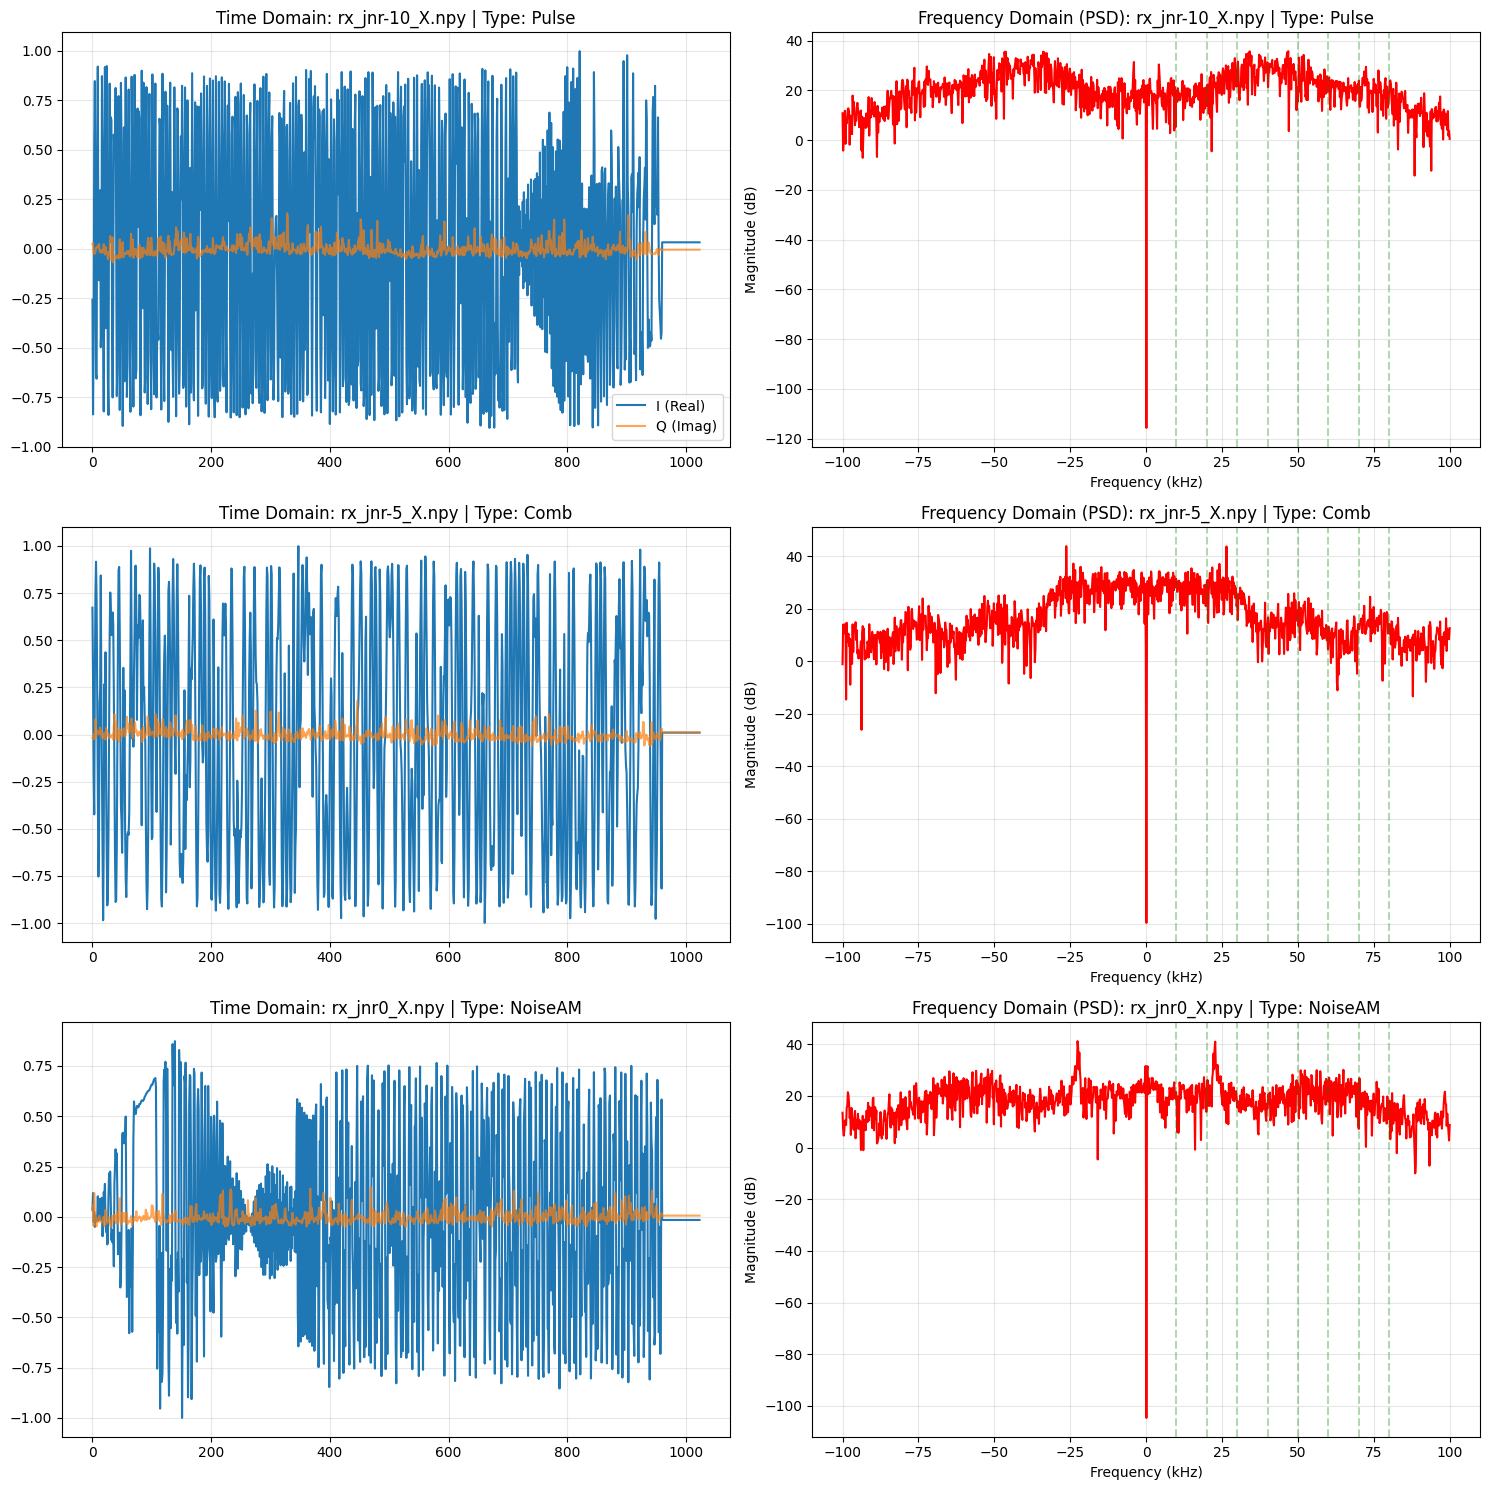

🔍 验证图已保存为 Data_Purity_Check.png
💡 检查要点：如果 PSD 图中绿色虚线位置出现与干扰信号无关的极细尖峰，说明标签桩残留，必须重做转换脚本！


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

def verify_dataset_purity(data_dir="/root/autodl-tmp/validate/0218/dataset_final_ready_v5/", num_samples=3):
    """
    可视化验证提取后的 1024 点负载是否残留了标签桩单音或同步头特征
    """
    # 类别映射表，方便观察不同干扰的特征
    type_names = ["SingleTone", "Chirp", "Pulse", "HoppingJam", "NoiseFM", "NoiseAM", "Comb", "Mixed"]
    
    # 获取所有 JNR 文件
    x_files = sorted([f for f in os.listdir(data_dir) if f.endswith('_X.npy')])
    
    if not x_files:
        print("❌ 错误：在目录中找不到 .npy 数据文件！")
        return

    plt.figure(figsize=(15, 5 * len(x_files[:3]))) # 仅展示前三个 JNR 文件进行检查

    for i, fx in enumerate(x_files[:3]): # 遍历前三个 JNR 文件 (如 -10dB, -5dB, 0dB)
        X = np.load(os.path.join(data_dir, fx))
        Y = np.load(os.path.join(data_dir, fx.replace('_X.npy', '_Y.npy')))
        
        # 随机抽取一个样本
        idx = np.random.randint(0, len(X))
        iq_data = X[idx, :, 0] + 1j * X[idx, :, 1]
        label = type_names[Y[idx]]
        
        # --- 1. 时域波形图 ---
        plt.subplot(len(x_files[:3]), 2, 2*i + 1)
        plt.plot(iq_data.real, label='I (Real)')
        plt.plot(iq_data.imag, label='Q (Imag)', alpha=0.7)
        plt.title(f"Time Domain: {fx} | Type: {label}")
        plt.grid(True, alpha=0.3)
        if i == 0: plt.legend()

        # --- 2. 频域 PSD 图 (验证标签是否切除的关键) ---
        plt.subplot(len(x_files[:3]), 2, 2*i + 2)
        psd = np.abs(np.fft.fftshift(np.fft.fft(iq_data, n=1024)))
        psd_db = 20 * np.log10(psd + 1e-12)
        freqs = np.linspace(-100, 100, 1024) # 对应 200k 采样率的 -100k ~ 100k
        
        plt.plot(freqs, psd_db, color='red')
        plt.title(f"Frequency Domain (PSD): {fx} | Type: {label}")
        plt.xlabel("Frequency (kHz)")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True, alpha=0.3)
        
        # 标注标签桩可能存在的频率区域 (10k, 20k, ... 80k)
        # 如果在这些垂直线位置出现了异常尖锐且固定高度的细柱，说明没切干净！
        for tag_f in range(10, 90, 10):
            plt.axvline(x=tag_f, color='green', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("Data_Purity_Check.png", dpi=300)
    plt.show()
    print("🔍 验证图已保存为 Data_Purity_Check.png")
    print("💡 检查要点：如果 PSD 图中绿色虚线位置出现与干扰信号无关的极细尖峰，说明标签桩残留，必须重做转换脚本！")

if __name__ == "__main__":
    verify_dataset_purity()